In [ ]:
%load_ext autoreload
%autoreload 2

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from config_file import config
from utils import FeatureEngineer, preprocessor

warnings.filterwarnings('ignore')

plt.style.use("fivethirtyeight")
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
train_data = pd.read_csv(config.paths.path_to_train)
train_data.set_index('PassengerId', inplace=True)

test_data = pd.read_csv(config.paths.path_to_test)
test_data.set_index('PassengerId', inplace=True)

In [7]:
train, test = train_data.copy(deep=True), test_data.copy(deep=True)
df = train

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


### EDA (Exploratory Data Analysis)

In [9]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


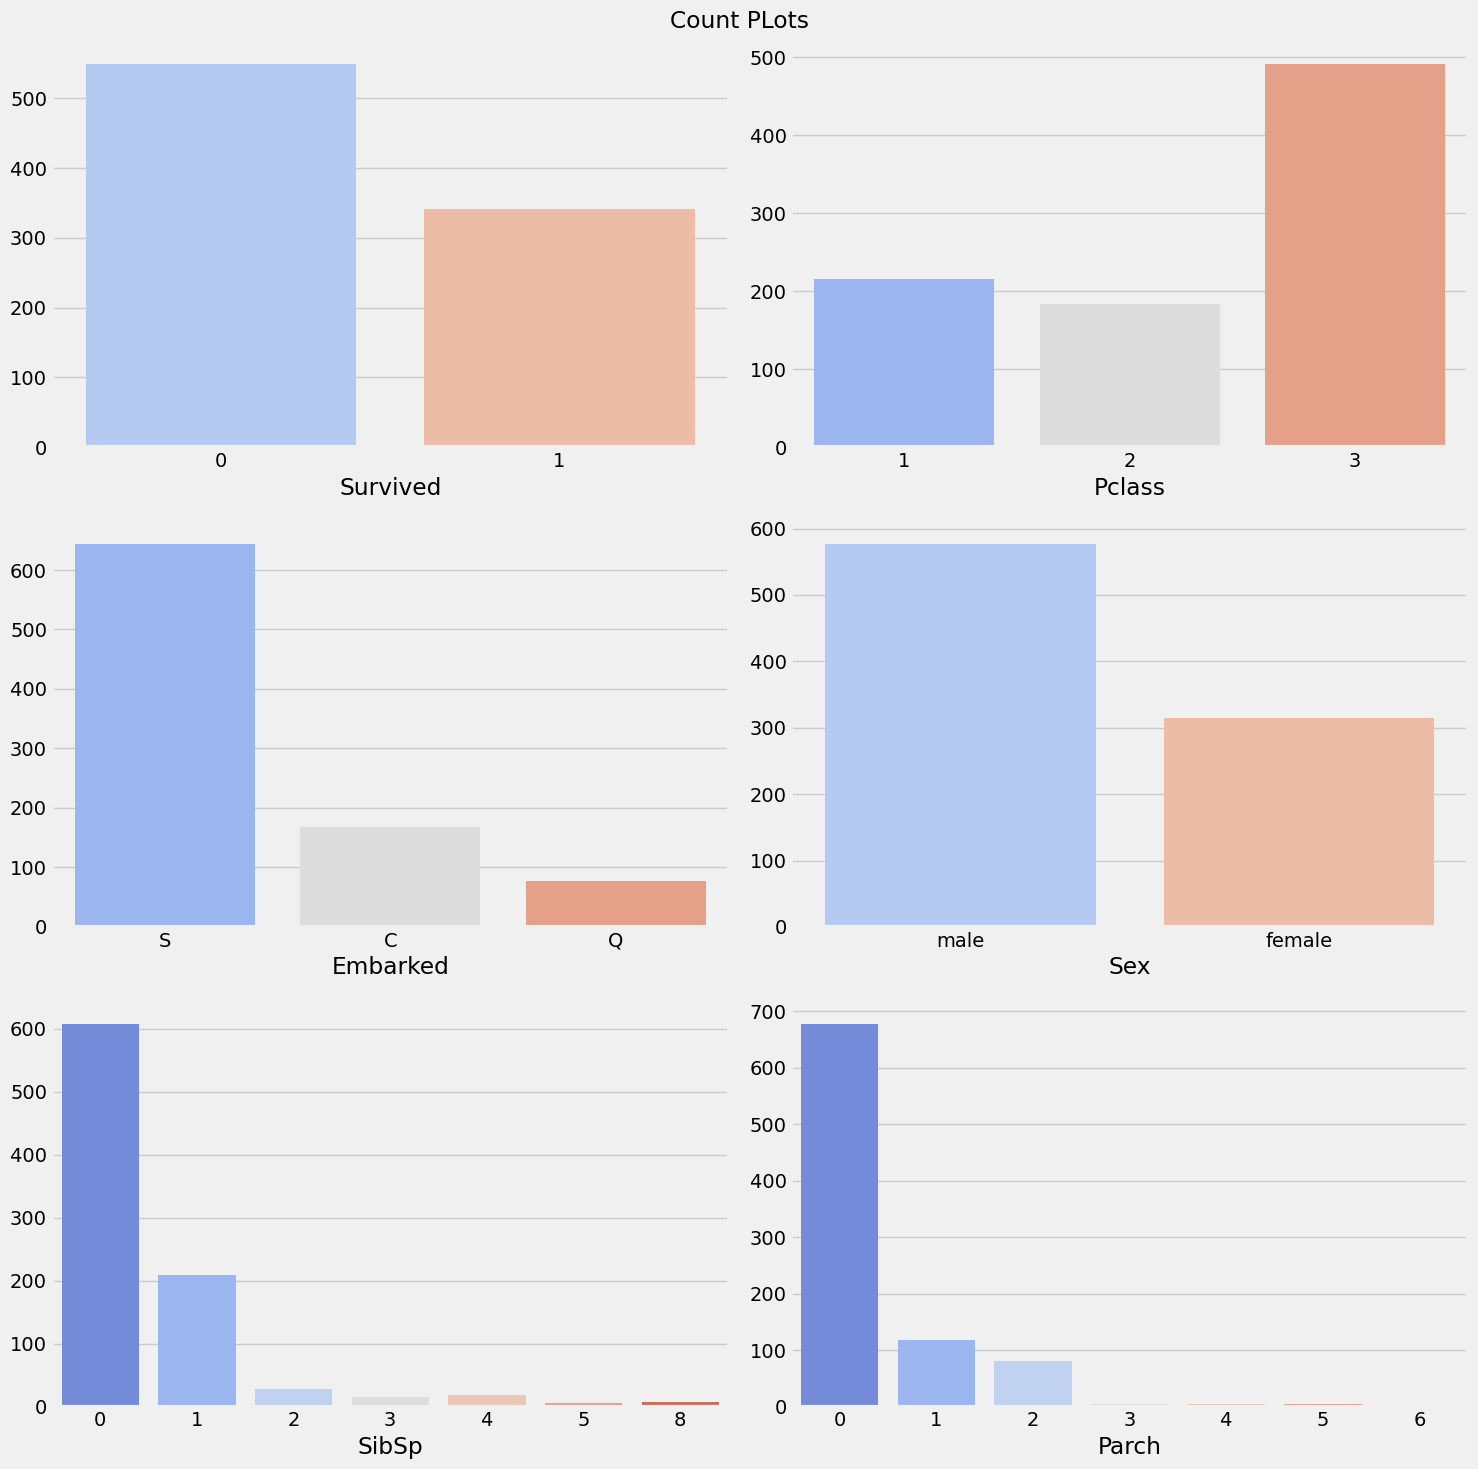

In [11]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(15,15))

fig.suptitle('Count PLots')

sns.countplot(df, x=config.target_column_name, palette='coolwarm', ax=ax[0, 0])
sns.countplot(df, x='Pclass', palette='coolwarm', ax=ax[0, 1])
sns.countplot(df, x='Embarked', palette='coolwarm', ax=ax[1, 0])
sns.countplot(df, x='Sex', palette='coolwarm', ax=ax[1, 1])
sns.countplot(df, x='SibSp', palette='coolwarm', ax=ax[2, 0])
sns.countplot(df, x='Parch', palette='coolwarm', ax=ax[2, 1])

[ax[i, j].set_ylabel('') for i in range(3) for j in range(2)]

plt.tight_layout()
plt.show()

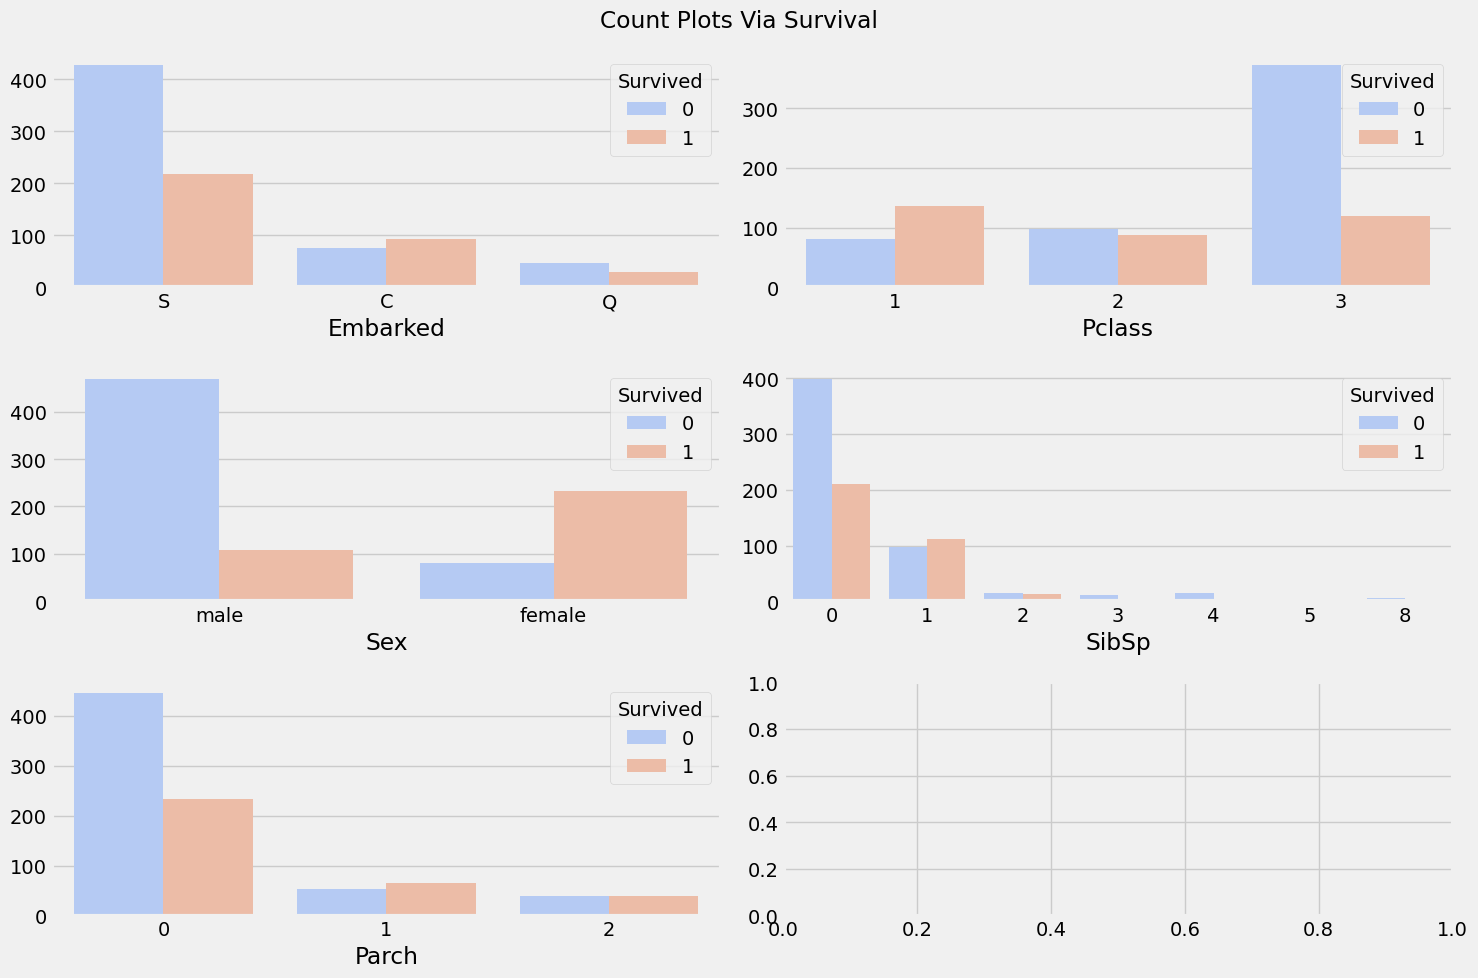

In [12]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(15,10))

fig.suptitle('Count Plots Via Survival')

sns.countplot(df, x='Embarked', palette='coolwarm', hue=config.target_column_name, ax=ax[0, 0])
sns.countplot(df, x='Pclass', palette='coolwarm', hue=config.target_column_name, ax=ax[0, 1])
sns.countplot(df, x='Sex', palette='coolwarm', hue=config.target_column_name, ax=ax[1, 0])
sns.countplot(df, x='SibSp', palette='coolwarm', hue=config.target_column_name, ax=ax[1, 1])
sns.countplot(df, x='Parch', palette='coolwarm', hue=config.target_column_name, order=[0, 1, 2], ax=ax[2, 0])

[ax[i, j].set_ylabel('') for i in range(3) for j in range(2)]

plt.tight_layout()
plt.show()

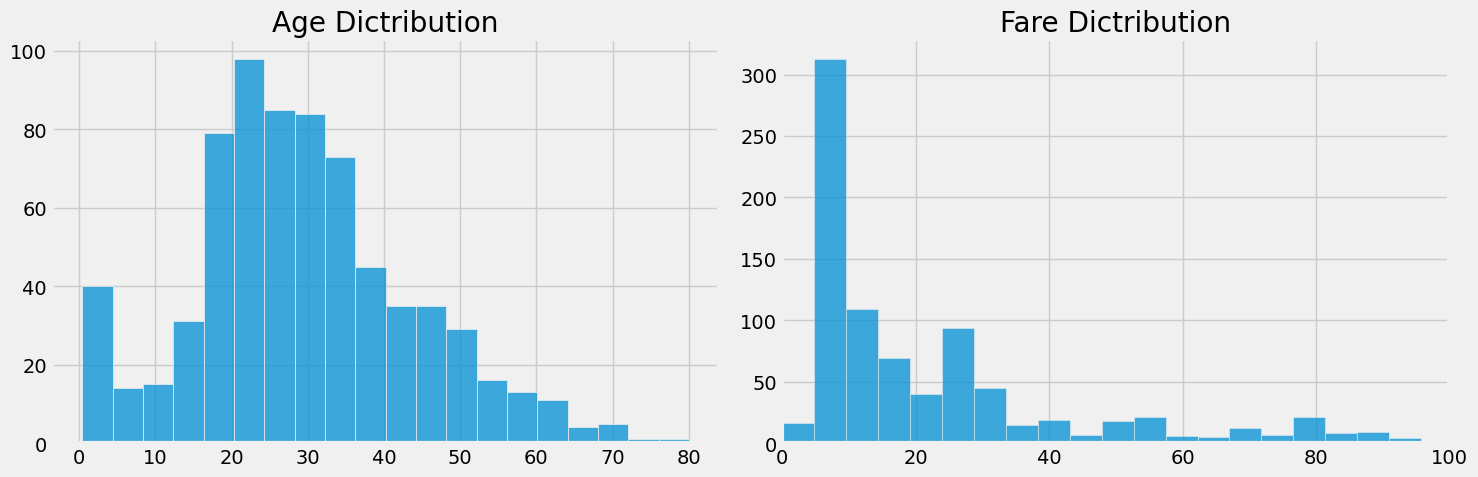

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

sns.histplot(df['Age'], ax=ax[0])
ax[0].set_title('Age Dictribution')


sns.histplot(df['Fare'], ax=ax[1])
ax[1].set_xlim(0, 100)
ax[1].set_title('Fare Dictribution')

[(ax[i].set_ylabel(''), ax[i].set_xlabel('')) for i in range(2)]

plt.tight_layout()
plt.show()

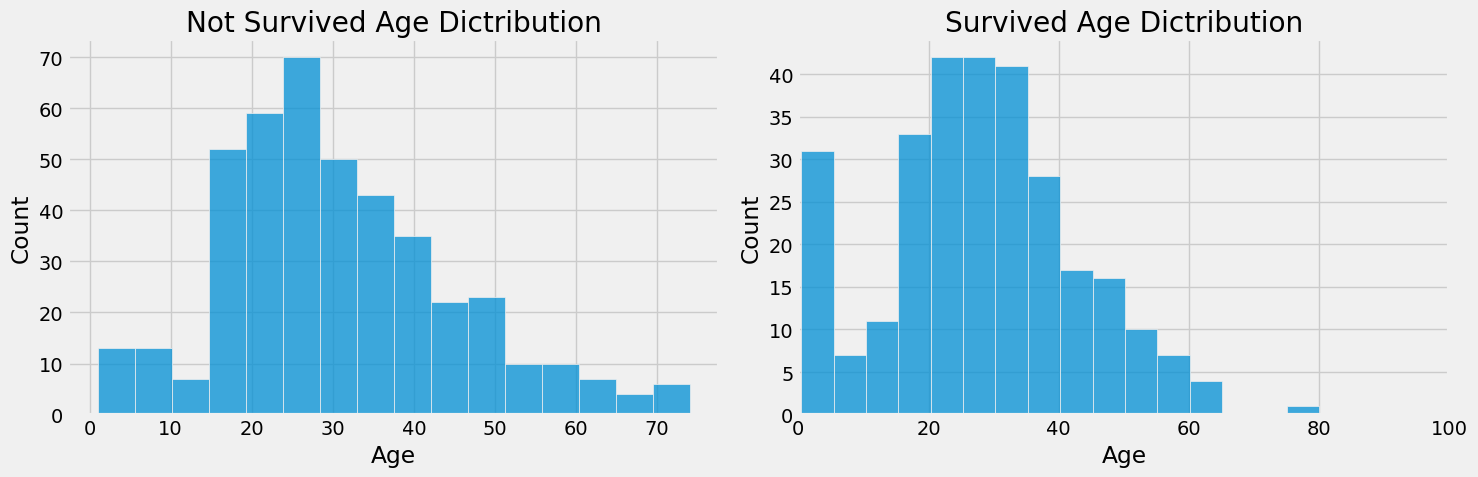

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

sns.histplot(df[df[config.target_column_name] == 0]['Age'], ax=ax[0])
ax[0].set_title('Not Survived Age Dictribution')


sns.histplot(df[df[config.target_column_name] == 1]['Age'], ax=ax[1])
ax[1].set_xlim(0, 100)
ax[1].set_title('Survived Age Dictribution')

plt.tight_layout()
plt.show()

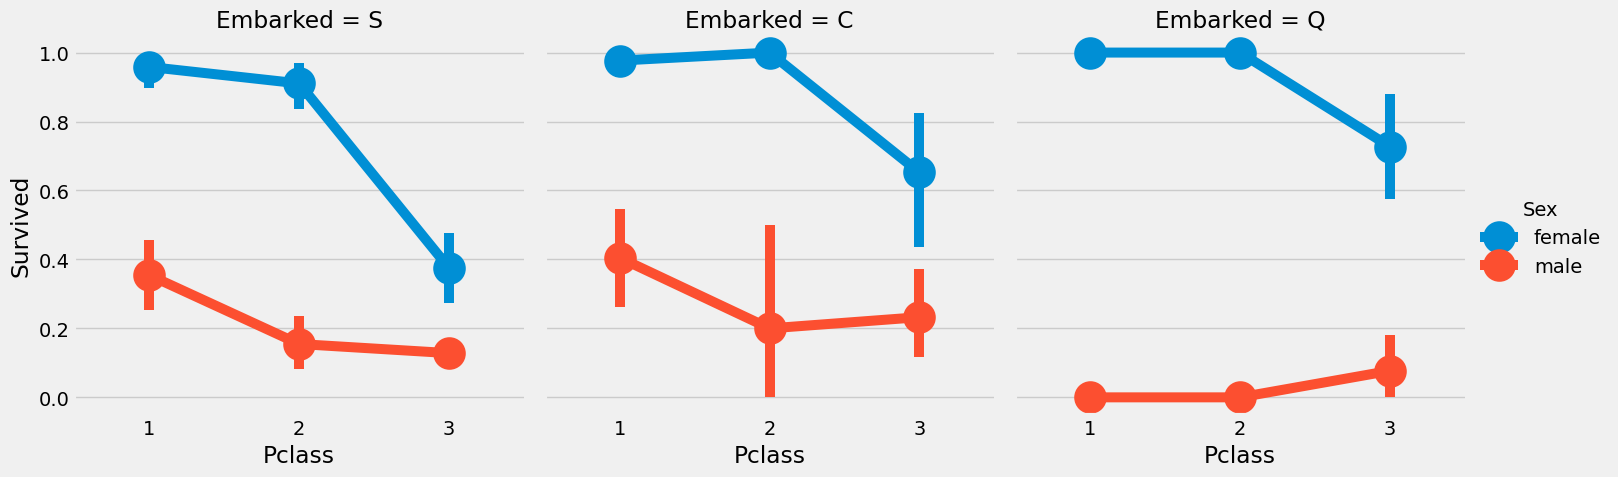

In [15]:
sns.catplot(data=df, x='Pclass',y=config.target_column_name,hue='Sex',col='Embarked', kind='point')
plt.show()

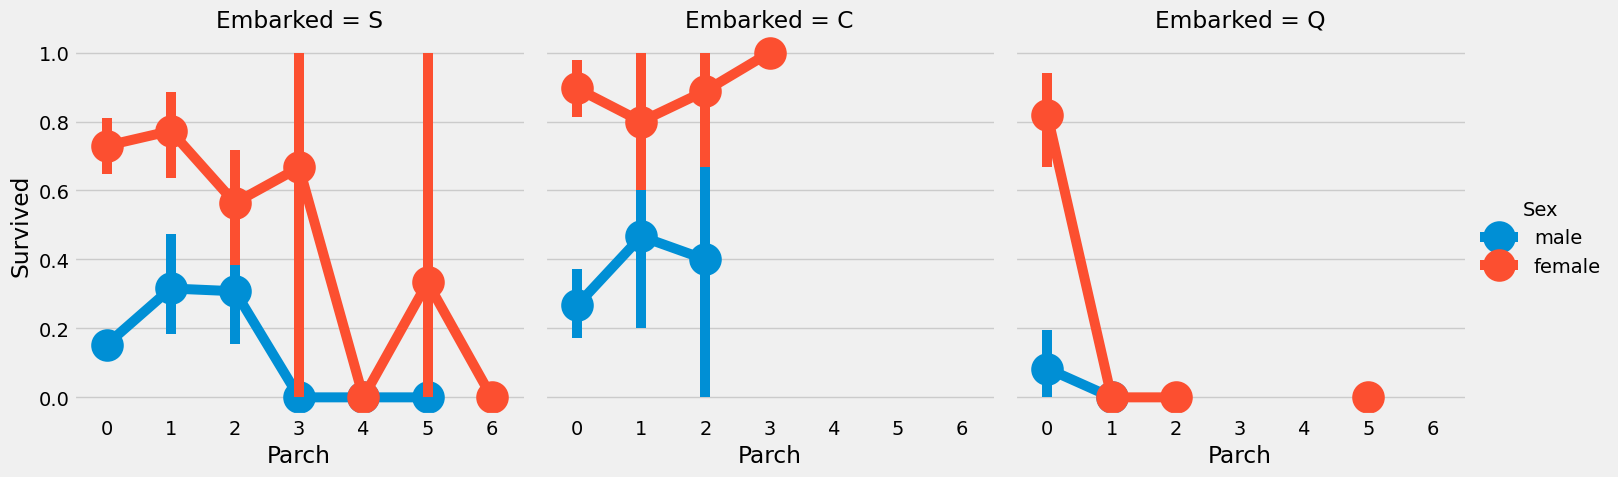

In [16]:
sns.catplot(data=df, x='Parch',y=config.target_column_name,hue='Sex',col='Embarked', kind='point')
plt.show()

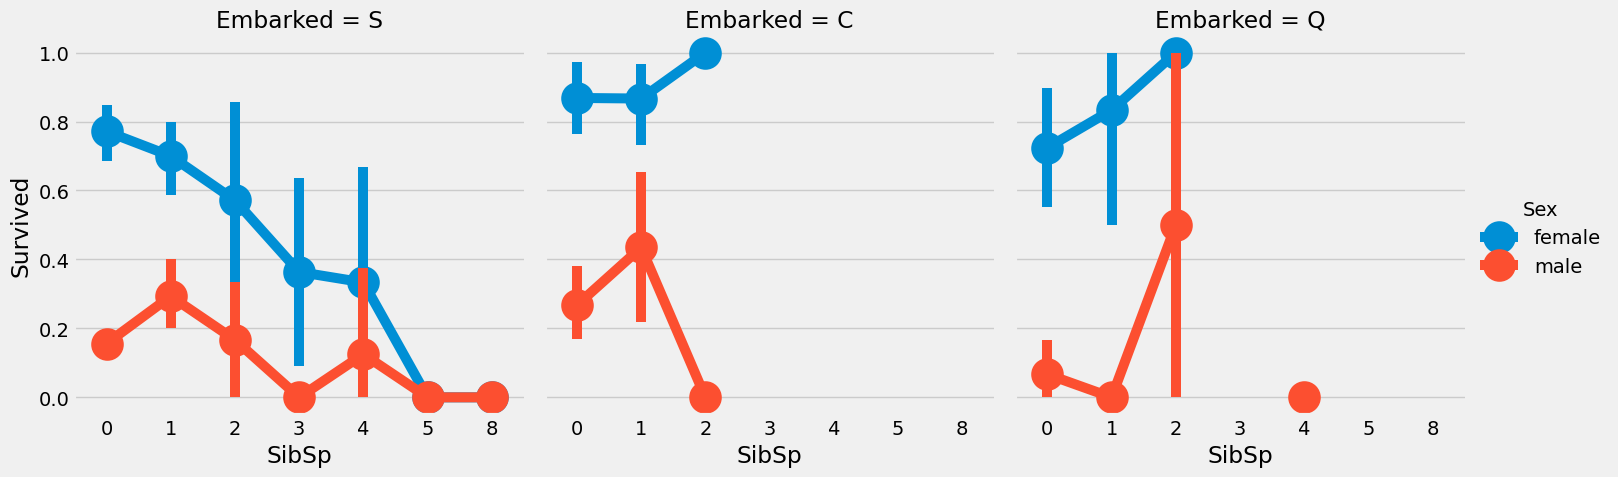

In [17]:
sns.catplot(data=df, x='SibSp',y=config.target_column_name,hue='Sex',col='Embarked', kind='point')
plt.show()

In [18]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [19]:
df[df['Embarked'].isnull()]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [20]:
# Номера билетов близкие к тем, что у людей с 
# пропусками выезжали из Sauthempton, поэтому 
# есть смысл заполнить их S (Sauthempton)
# Также подавляющее большинство пассажиров садились на борт именно в S (Sauthempton)

df[(df['Pclass'] == 1) & 
   (df['Sex'] == 'female') & 
   (df[config.target_column_name] == 1) & 
   (df['SibSp'] == 0) & 
   (df['Parch'] == 0)]\
   [['Embarked']].value_counts()

Embarked
C           17
S           14
Name: count, dtype: int64

In [21]:
pd.crosstab(df.Parch, df.Pclass, margins=True).style.background_gradient(cmap='summer_r')

Pclass,1,2,3,All
Parch,,,,
0,163,134,381,678
1,31,32,55,118
2,21,16,43,80
3,0,2,3,5
4,1,0,3,4
5,0,0,5,5
6,0,0,1,1
All,216,184,491,891


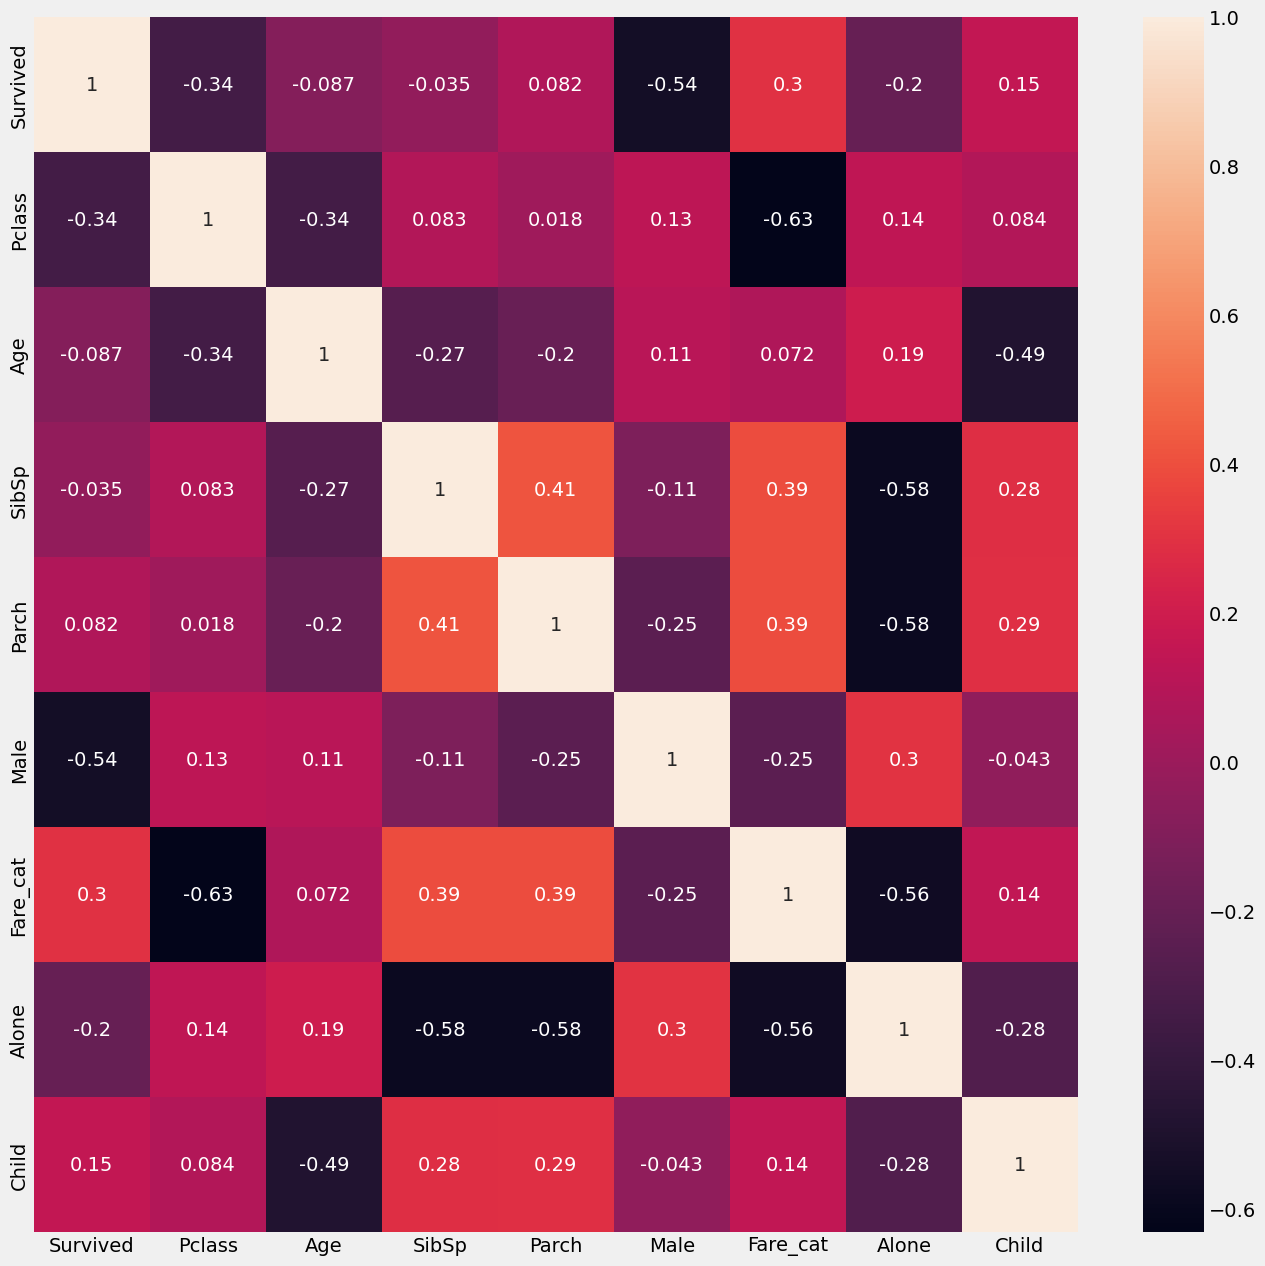

In [ ]:
df1 = FeatureEngineer().fit_transform(df)

fig = plt.figure(figsize=(15,15))
sns.heatmap(df1.drop(columns=['Initial', 'Embarked']).corr(), annot=True)
plt.show()

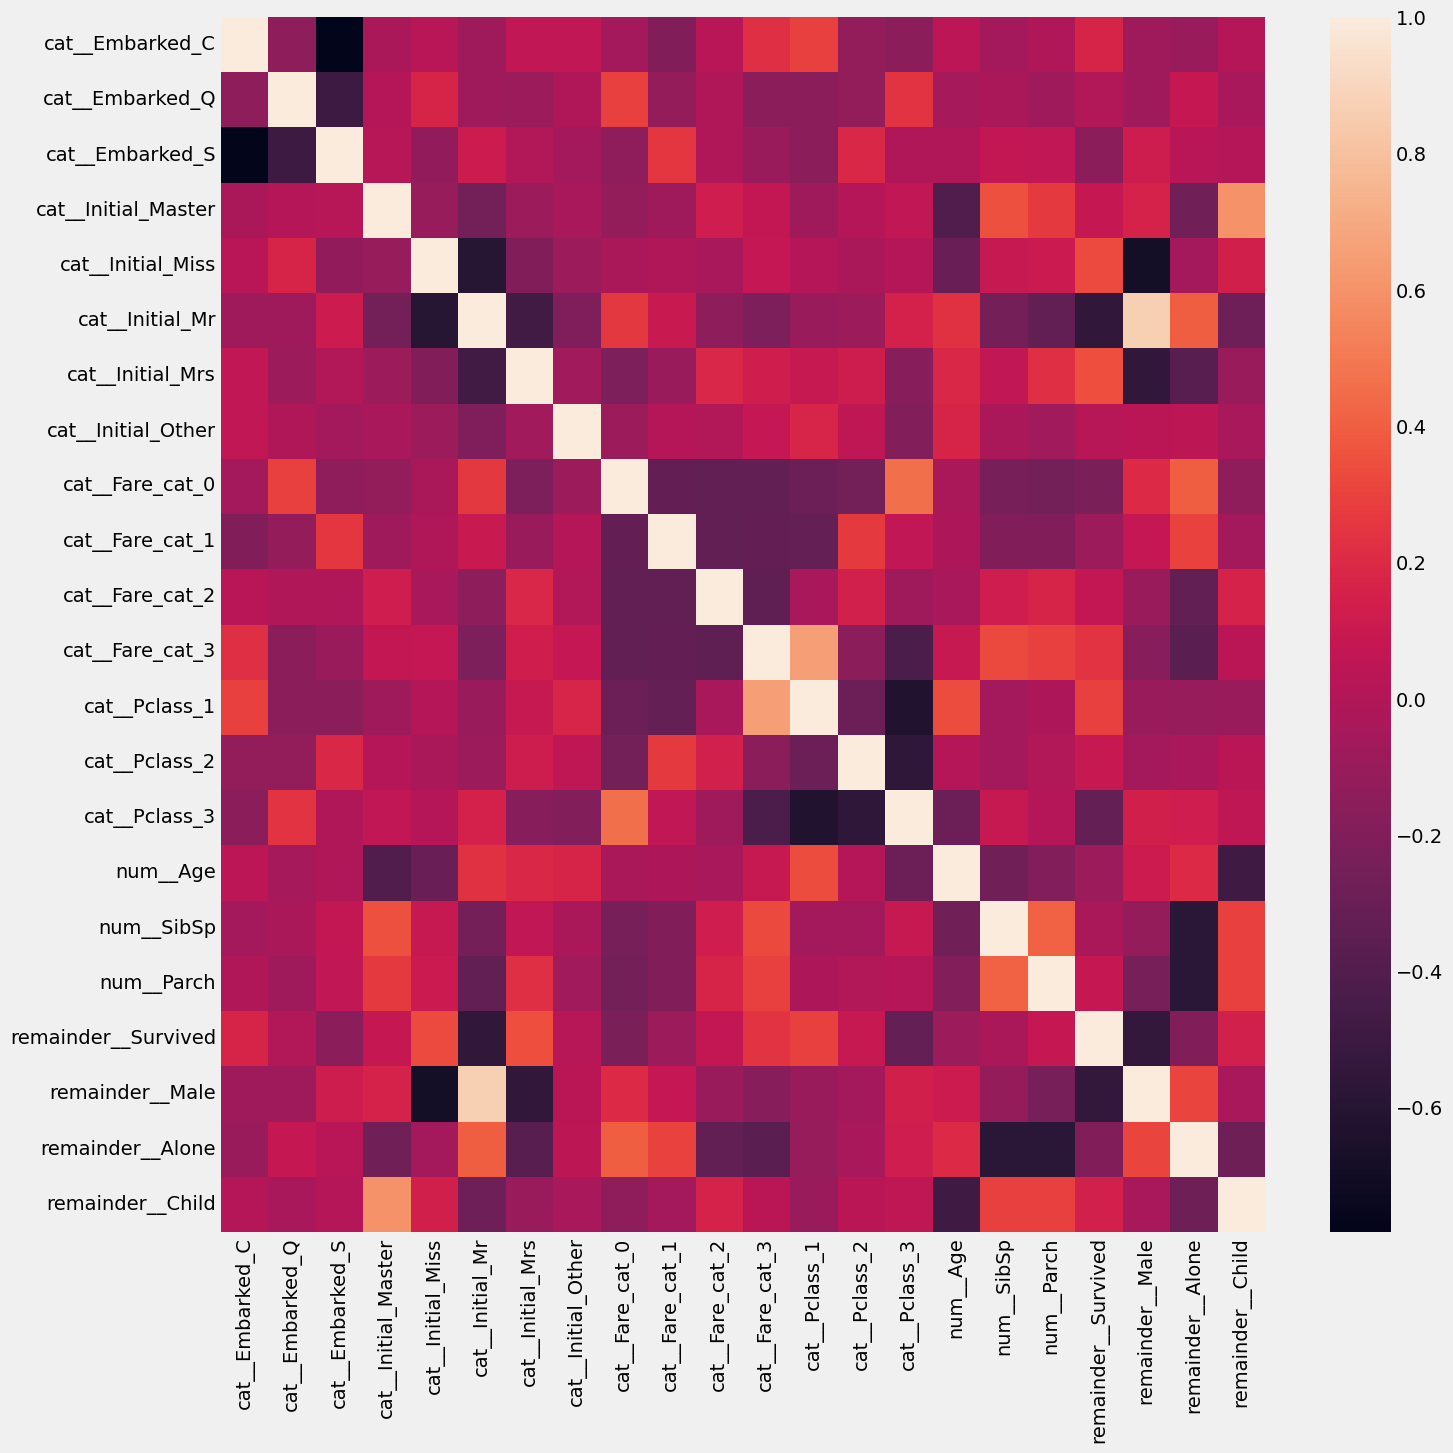

In [35]:
df2 = df.copy(deep=True)

proc = preprocessor(True, True)

np_array = proc.fit_transform(df2)

feature_names = proc.named_steps['cols_transformer'].get_feature_names_out()

df2 = pd.DataFrame(np_array, columns=feature_names, index=df2.index)

fig = plt.figure(figsize=(15,15))
sns.heatmap(df2.corr())
plt.show()
